<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/C%C3%B3pia_de_RELATORIO_FINAL_VICTOR_CUENCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, roc_curve, auc
import shap


In [ ]:
#CARREGAR DADOS
from google.colab import files
uploaded = files.upload()

Saving iiot_30min_norm.csv to iiot_30min_norm.csv


R² = 0.9920 | RMSE = 0.6419 | MAE = 0.5600


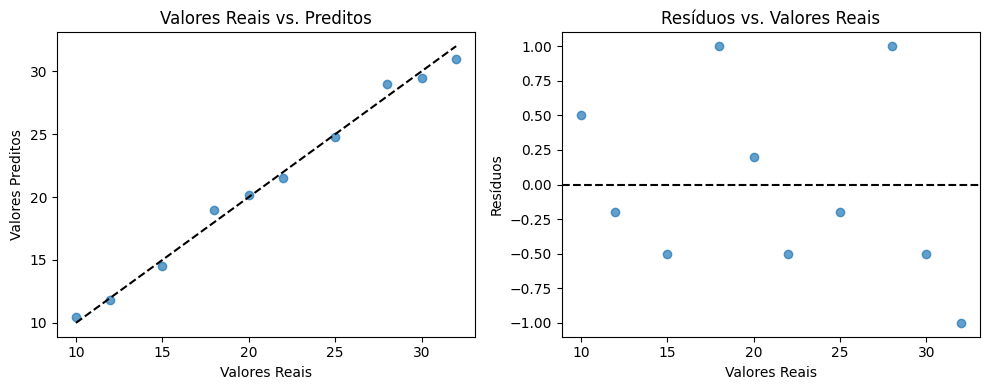

In [ ]:
import numpy as np

# TROQUE pelos seus vetores reais e preditos
# Exemplo com dados de placeholder (SUBSTITUA PELOS SEUS DADOS REAIS)
y_true = np.array([10, 12, 15, 18, 20, 22, 25, 28, 30, 32])
y_pred = np.array([10.5, 11.8, 14.5, 19.0, 20.2, 21.5, 24.8, 29.0, 29.5, 31.0])

# y_true = y_test              # ex.: y_test
# y_pred = y_pred_mlp          # ex.: previsões do seu modelo

# Cálculo das métricas (opcional, só pra conferir)
r2  = r2_score(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
print(f"R² = {r2:.4f} | RMSE = {rmse:.4f} | MAE = {mae:.4f}")

# Gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Gráfico 1: Valores Reais vs. Valores Preditos ---
axes[0].scatter(y_true, y_pred, alpha=0.7)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--')  # linha 45°
axes[0].set_xlabel("Valores Reais")
axes[0].set_ylabel("Valores Preditos")
axes[0].set_title("Valores Reais vs. Preditos")

# --- Gráfico 2: Resíduos vs. Valores Reais ---
residuos = y_pred - y_true
axes[1].scatter(y_true, residuos, alpha=0.7)
axes[1].axhline(0, linestyle='--', color='k')
axes[1].set_xlabel("Valores Reais")
axes[1].set_ylabel("Resíduos")
axes[1].set_title("Resíduos vs. Valores Reais")

plt.tight_layout()
plt.show()

AUC = 0.6272


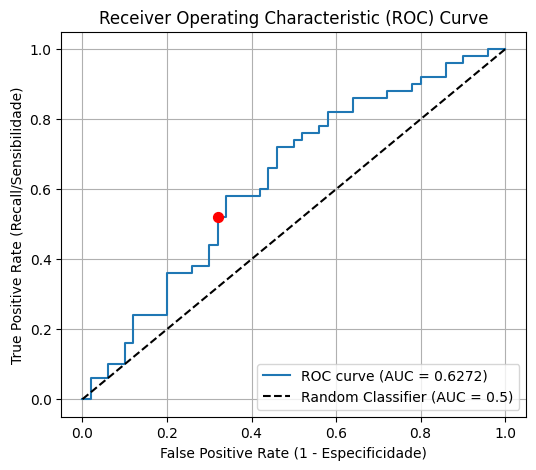

In [ ]:
import numpy as np

# TROQUE pelos seus dados
# Exemplo com dados de placeholder (SUBSTITUA PELOS SEUS DADOS REAIS)
y_true_cls = np.random.randint(0, 2, 100)  # rótulos reais (0 ou 1)
y_score = np.random.rand(100)              # probabilidade da classe 1

# y_true_cls = y_test          # ex.: rótulos reais (0/1)
# y_score = modelo_clf.predict_proba(X_test)[:, 1]  # ex.: probabilidade da classe 1

fpr, tpr, thresholds = roc_curve(y_true_cls, y_score)
roc_auc = auc(fpr, tpr)
print(f"AUC = {roc_auc:.4f}")

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier (AUC = 0.5)")

# ponto para threshold ~0.5 (opcional)
# Verifica se thresholds não está vazio antes de tentar indexar
if len(thresholds) > 0:
    idx_05 = np.argmin(np.abs(thresholds - 0.5))
    plt.scatter(fpr[idx_05], tpr[idx_05], s=50, color='red', marker='o', zorder=5)

plt.xlabel("False Positive Rate (1 - Especificidade)")
plt.ylabel("True Positive Rate (Recall/Sensibilidade)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

/tmp/ipython-input-3178232779.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain)


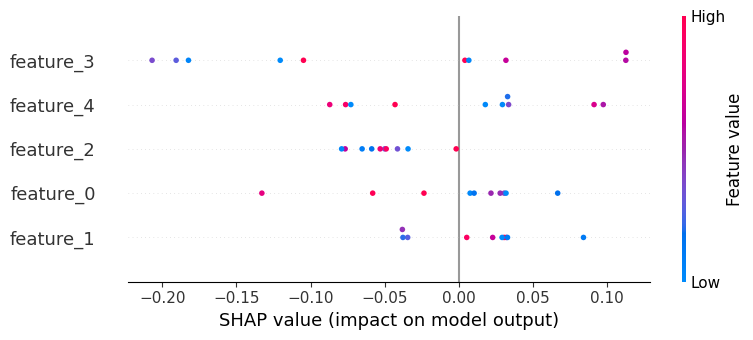

/tmp/ipython-input-3178232779.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, plot_type="bar")


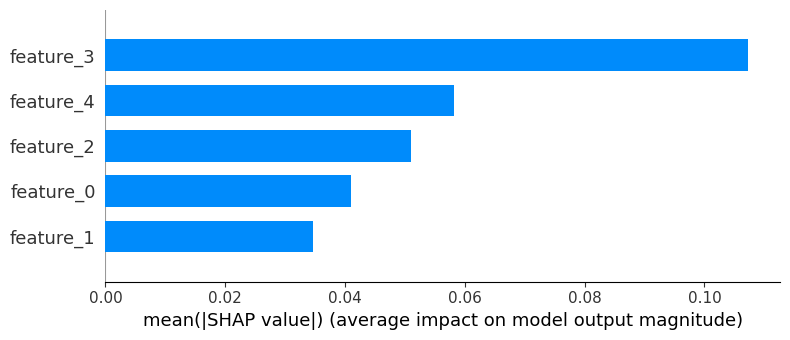

In [ ]:
import xgboost as xgb
import pandas as pd

# Gerar dados de exemplo para o modelo e para X_explain
np.random.seed(42)
X_train_dummy = pd.DataFrame(np.random.rand(100, 5), columns=[f'feature_{i}' for i in range(5)])
y_train_dummy = np.random.rand(100)

# Criar e treinar um modelo XGBoost de exemplo
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=10)
xgb_model.fit(X_train_dummy, y_train_dummy)

X_explain = pd.DataFrame(np.random.rand(10, 5), columns=[f'feature_{i}' for i in range(5)]) # dados para explicação

# Criar o explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_explain)

# --- Gráfico 1: SHAP summary (tipo "swarm") ---
shap.summary_plot(shap_values, X_explain)

# --- Gráfico 2: SHAP - barras (importância média) ---
shap.summary_plot(shap_values, X_explain, plot_type="bar")